Simulando d=3...
  done (aceptación media: 70.5%)
Simulando d=5...
  done (aceptación media: 41.8%)
Simulando d=7...
  done (aceptación media: 25.1%)


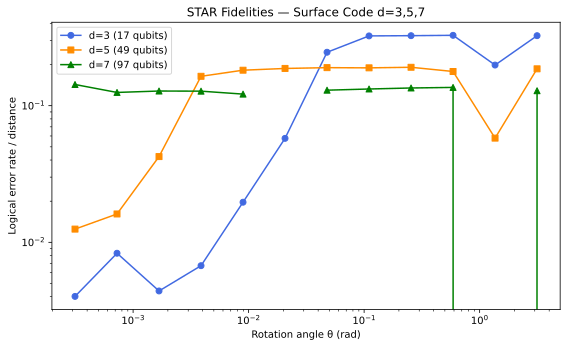

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from tsim import Circuit

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

def load_stim_with_angle(path: str, d: int, logical_angle_in_pi: float) -> Circuit:
    phys_rad = physical_angle(logical_angle_in_pi, d) * np.pi
    with open(path) as f:
        circ_str = f.read()
    # Reemplazar solo la primera R_Z (la rotación física, no la des-rotación final)
    circ_str = re.sub(r'R_Z\([^)]+\)', f'R_Z({phys_rad:.10f})', circ_str, count=1)
    return Circuit(circ_str)

# ── Simulación ───────────────────────────────────────────────────────────────
distances  = [3, 5, 7]
angle_vals = np.logspace(-4, 0, 12)
shots      = 1_000
results    = {d: [] for d in distances}

for d in distances:
    print(f"Simulando d={d}...")
    num_postselect = 3 * (d**2 - 1)  # 24, 72, 144 para d=3,5,7

    for angle_pi in angle_vals:
        circ = load_stim_with_angle(
            f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=angle_pi
        )
        sampler = circ.compile_detector_sampler()
        try:
            samples = sampler.sample(shots=shots, append_observables=True, batch_size=10)
        except AssertionError:
            results[d].append(np.nan)
            continue

        detectors  = samples[:, :-1]
        observable = samples[:, -1]

        # Postselección: descartar shots con cualquier error en la fase de preparación
        mask   = ~np.any(detectors[:, :num_postselect], axis=1)
        n_kept = mask.sum()

        if n_kept == 0:
            results[d].append(np.nan)
            continue

        # Fidelidad: fracción de shots limpios donde el observable fue 1 (error lógico)
        logical_errors = observable[mask].sum()
        results[d].append(logical_errors / n_kept / d)

    print(f"  done (aceptación media: {np.nanmean([mask.mean()])*100:.1f}%)")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
styles = {
    3: ("royalblue",  "o", "d=3 (17 qubits)"),
    5: ("darkorange", "s", "d=5 (49 qubits)"),
    7: ("green",      "^", "d=7 (97 qubits)"),
}
for d in distances:
    color, marker, label = styles[d]
    ax.plot(angle_vals * np.pi, results[d],
            color=color, marker=marker, label=label, linewidth=1.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend()
ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout()
plt.show()


Simulando d=3...
  angle=3.14e-04 | kept=1633/2000 | errors=36 | rate=7.35e-03
  angle=1.17e-03 | kept=1595/2000 | errors=31 | rate=6.48e-03
  angle=4.37e-03 | kept=1556/2000 | errors=28 | rate=6.00e-03
  angle=1.63e-02 | kept=1451/2000 | errors=36 | rate=8.27e-03
  angle=6.07e-02 | kept=1240/2000 | errors=28 | rate=7.53e-03
  angle=2.26e-01 | kept=888/2000 | errors=17 | rate=6.38e-03
  angle=8.43e-01 | kept=483/2000 | errors=12 | rate=8.28e-03
  angle=3.14e+00 | kept=1627/2000 | errors=35 | rate=7.17e-03
  done
Simulando d=5...
  angle=3.14e-04 | kept=1003/2000 | errors=61 | rate=1.22e-02
  angle=1.17e-03 | kept=900/2000 | errors=58 | rate=1.29e-02
  angle=4.37e-03 | kept=708/2000 | errors=39 | rate=1.10e-02
  angle=1.63e-02 | kept=600/2000 | errors=41 | rate=1.37e-02
  angle=6.07e-02 | kept=380/2000 | errors=21 | rate=1.11e-02
  angle=2.26e-01 | kept=196/2000 | errors=9 | rate=9.18e-03
  angle=8.43e-01 | kept=76/2000 | errors=1 | rate=2.63e-03
  angle=3.14e+00 | kept=1138/2000 | erro

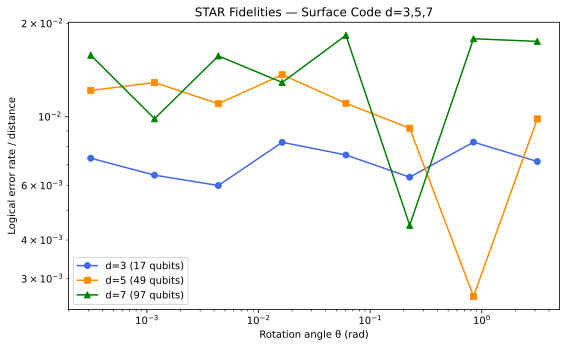

In [ ]:
def load_stim_with_angle(path: str, d: int, logical_angle_in_pi: float) -> Circuit:
    phys_angle_in_pi = physical_angle(logical_angle_in_pi, d)  # ya en unidades de π
    with open(path) as f:
        circ_str = f.read()
    matches = list(re.finditer(r'R_Z\([^)]+\)', circ_str))
    # Reemplazar de atrás hacia adelante para no invalidar índices
    last = matches[-1]
    circ_str = circ_str[:last.start()] + f'R_Z({-logical_angle_in_pi:.10f})' + circ_str[last.end():]
    first = matches[0]
    circ_str = circ_str[:first.start()] + f'R_Z({phys_angle_in_pi:.10f})' + circ_str[first.end():]
    return Circuit(circ_str)

# ── Simulación ───────────────────────────────────────────────────────────────
distances  = [3, 5, 7]
angle_vals = np.logspace(-4, 0, 8)
shots      = 2_000
results    = {d: [] for d in distances}

for d in distances:
    print(f"Simulando d={d}...")
    num_postselect = 3 * (d**2 - 1)

    for angle_pi in angle_vals:
        circ = load_stim_with_angle(
            f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=angle_pi
        )
        sampler = circ.compile_detector_sampler()
        try:
            detector_events, observable_events = sampler.sample(
                shots=shots, separate_observables=True, batch_size=100
            )
        except AssertionError:
            results[d].append(np.nan)
            continue

        mask   = ~np.any(detector_events[:, :num_postselect], axis=1)
        n_kept = mask.sum()

        if n_kept == 0:
            results[d].append(np.nan)
            continue

        # PyMatching corrige errores post-rotación
        predicted      = matcher.decode_batch(detector_events[mask])
        logical_errors = np.sum(predicted.flatten() != observable_events[mask].flatten())
        rate = logical_errors / n_kept / d
        results[d].append(rate if rate > 0 else np.nan)
        print(f"  angle={angle_pi*np.pi:.2e} | kept={n_kept}/{shots} | errors={logical_errors} | rate={rate:.2e}")

    print(f"  done")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
styles = {
    3: ("royalblue",  "o", "d=3 (17 qubits)"),
    5: ("darkorange", "s", "d=5 (49 qubits)"),
    7: ("green",      "^", "d=7 (97 qubits)"),
}
for d in distances:
    color, marker, label = styles[d]
    vals = [(a*np.pi, r) for a, r in zip(angle_vals, results[d]) if not np.isnan(r)]
    if vals:
        xs, ys = zip(*vals)
        ax.plot(xs, ys, color=color, marker=marker, label=label, linewidth=1.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend()
ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout()
plt.show()

Simulando d=3...
  done
Simulando d=5...
  done
Simulando d=7...
  done


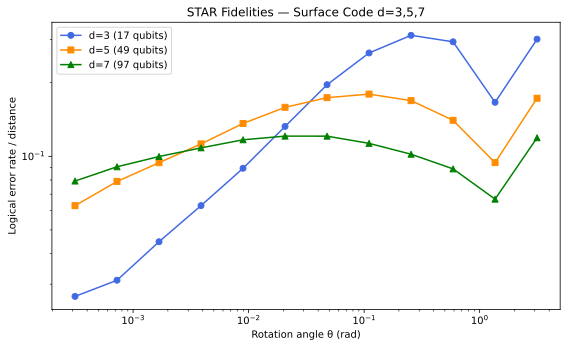

In [ ]:
distances  = [3, 5, 7]
angle_vals = np.logspace(-4, 0, 12)
shots      = 5_000
results    = {d: [] for d in distances}

for d in distances:
    print(f"Simulando d={d}...")
    for angle_pi in angle_vals:
        circ = load_stim_with_angle(
            f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=angle_pi
        )
        sampler = circ.compile_detector_sampler()
        dets, obs = sampler.sample(shots=shots, separate_observables=True)
        logical_errors = obs[:, 0].sum()
        results[d].append(logical_errors / shots / d)
    print(f"  done")

fig, ax = plt.subplots(figsize=(8, 5))
styles = {3: ("royalblue", "o", "d=3 (17 qubits)"),
          5: ("darkorange", "s", "d=5 (49 qubits)"),
          7: ("green",      "^", "d=7 (97 qubits)")}
for d in distances:
    color, marker, label = styles[d]
    ax.plot(angle_vals * np.pi, results[d],
            color=color, marker=marker, label=label, linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend()
ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout()
plt.show()


Simulando d=3...
  done
Simulando d=5...
  done
Simulando d=7...
  done


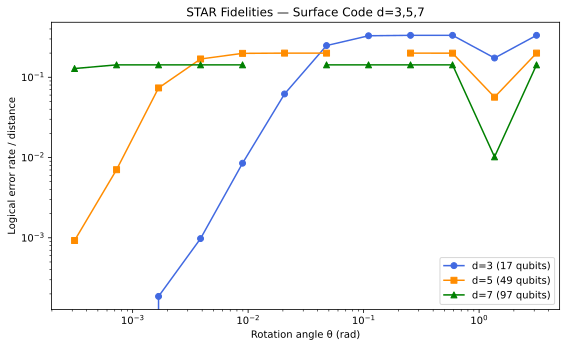

In [ ]:
def load_stim_with_angle(path: str, d: int, logical_angle_in_pi: float) -> Circuit:
    with open(path) as f:
        circ_str = f.read()
    phys_rad = physical_angle(logical_angle_in_pi, d) * np.pi
    circ_str = re.sub(r'R_Z\([^)]+\)', f'R_Z({phys_rad:.10f})', circ_str, count=1)
    return Circuit(circ_str)  # tsim.Circuit, maneja R_Z

# ── Simulación ──────────────────────────────────────────────────────────────
distances  = [3, 5, 7]
angle_vals = np.logspace(-4, 0, 12)
shots      = 10_000
results    = {d: [] for d in distances}

for d in distances:
    print(f"Simulando d={d}...")
    for angle_pi in angle_vals:
        circ = load_stim_with_angle(
            f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=angle_pi
        )
        sampler = circ.compile_detector_sampler()
        
        try:
            samples = sampler.sample(shots=shots, append_observables=True, batch_size=50)
        except AssertionError:
            results[d].append(np.nan)
            continue

        detectors  = samples[:, :-1]
        observable = samples[:, -1]

        mask   = ~np.any(detectors, axis=1)
        n_kept = mask.sum()

        if n_kept == 0:
            results[d].append(np.nan)
        else:
            logical_errors = observable[mask].sum()
            results[d].append(logical_errors / n_kept / d)
    print("  done")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
styles = {
    3: ("royalblue",  "o", "d=3 (17 qubits)"),
    5: ("darkorange", "s", "d=5 (49 qubits)"),
    7: ("green",      "^", "d=7 (97 qubits)"),
}
for d in distances:
    color, marker, label = styles[d]
    ax.plot(angle_vals * np.pi, results[d],
            color=color, marker=marker, label=label, linewidth=1.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend()
ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout()
plt.show()

In [ ]:
import re, numpy as np, matplotlib.pyplot as plt
from tsim import Circuit
import pymatching

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

def load_stim_with_angle(path, d, logical_angle_in_pi):
    phys = physical_angle(logical_angle_in_pi, d)
    with open(path) as f: circ_str = f.read()
    matches = list(re.finditer(r'R_Z\([^)]+\)', circ_str))
    last = matches[-1]
    circ_str = circ_str[:last.start()] + f'R_Z({-logical_angle_in_pi:.10f})' + circ_str[last.end():]
    first = matches[0]
    circ_str = circ_str[:first.start()] + f'R_Z({phys:.10f})' + circ_str[first.end():]
    return Circuit(circ_str)

distances      = [3, 5, 7]
angle_vals_rad = np.logspace(-3, 0, 8)
shots          = 5_000
results        = {d: [] for d in distances}

for d in distances:
    print(f"\nd={d}...")
    num_postselect = 3 * (d**2 - 1)
    dem     = load_stim_with_angle(f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=0.0).stim_circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    for theta_rad in angle_vals_rad:
        circ    = load_stim_with_angle(f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=theta_rad/np.pi)
        sampler = circ.compile_detector_sampler()
        try:
            det_ev, obs_ev = sampler.sample(shots=shots, separate_observables=True, batch_size=1)
        except AssertionError:
            results[d].append(np.nan); continue
        mask   = ~np.any(det_ev[:, :num_postselect], axis=1)
        n_kept = mask.sum()
        if n_kept == 0: results[d].append(np.nan); continue
        predicted      = matcher.decode_batch(det_ev[mask])
        logical_errors = np.sum(predicted.flatten() != obs_ev[mask].flatten())
        rate = logical_errors / n_kept / d
        results[d].append(rate if rate > 0 else np.nan)
        print(f"  θ={theta_rad:.2e} | kept={n_kept} | err={logical_errors} | rate={rate:.2e}")

fig, ax = plt.subplots(figsize=(8,5))
for d, (color, marker, label) in zip(distances, [("royalblue","o","d=3 (17 qubits)"),("darkorange","s","d=5 (49 qubits)"),("green","^","d=7 (97 qubits)")]):
    vals = [(t,r) for t,r in zip(angle_vals_rad, results[d]) if not np.isnan(r)]
    if vals: ax.plot(*zip(*vals), color=color, marker=marker, label=label, linewidth=1.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)"); ax.set_ylabel("Logical error rate / distance")
ax.legend(); ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout(); plt.show()


d=3...
